# Gene–Pathway Interaction Network Construction

Construct a gene–gene interaction dataset derived from pathway relationships and enrichment statistics.  
It integrates driver gene annotations, pathway mappings, and Reactome relationships to generate biologically meaningful gene pairs for downstream graph-based learning.

## 1. Configuration
Define the input data sources, pathway filtering parameters, and graph construction settings. The configuration specifies the maximum number of genes per pathway, whether random truncation is applied to reduce ordering bias, and whether pathway size limits are enforced during preprocessing. The interaction labels are mapped into $y \in \{-1, 0, 1\}$, where $-1$ denotes inhibitory interactions, $0$ denotes neutral interactions, and $1$ denotes activating interactions between genes. These labels are derived from pathway enrichment significance and are used to guide downstream graph-based learning.


In [1]:
import pandas as pd
import numpy as np
from itertools import product
from tqdm.auto import tqdm
import random
import os

tqdm.pandas()

# ==============================
# CONFIG
# ==============================
MAX_GENES_PER_PATHWAY = 5000
RANDOM_TRUNCATION = False
APPLY_LIMIT = True   # True = limit, False = keep ALL genes

OUTPUT_DIR = "data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Subfolder (under OUTPUT_DIR) where per-cancer multi-omics graph CSVs are saved
graphs_multiomics = "graphs_multiomics"

## 2. Driver and Non-Driver Gene Sets

Load curated lists of Cancer driver genes and Non-driver genes.
These are later used to assign gene_type labels for supervised learning.

In [2]:
drivers = set(
    pd.read_table("data/processed/driver_genes.txt", header=None)[0].astype(str).str.upper()
)
nondrivers = set(
    pd.read_table("data/processed/non_driver_genes.txt", header=None)[0].astype(str).str.upper()
)
unlabeled = set(
    pd.read_table("data/processed/unlabeled_genes.txt", header=None)[0].astype(str).str.upper()
)

if drivers & nondrivers or drivers & unlabeled or nondrivers & unlabeled:
    raise ValueError("Driver, non-driver, and unlabeled sets must be disjoint.")

node_labels = {gene: 1 for gene in drivers}
node_labels.update({gene: 0 for gene in nondrivers})
node_labels.update({gene: -1 for gene in unlabeled})

print(
    f"Drivers: {len(drivers)}, Non-drivers: {len(nondrivers)}, "
    f"Unlabeled: {len(unlabeled)}"
)

Drivers: 687, Non-drivers: 2806, Unlabeled: 16577


## 3. Pathway Enrichment Data

Load enrichment statistics for each pathway:
- p-value
- significance label
This information is propagated to gene pairs during graph construction.

In [3]:
enrichment = pd.read_csv(
    "../reactome_embedding/results/enrichment/enrichment_simple.csv"
)[["stId", "p_value", "significance"]]

enrichment_dict = enrichment.set_index("stId").to_dict("index")

## 4. Pathway-to-Gene Mapping

Map each pathway to its constituent genes.
Optional preprocessing:
- Random truncation (to avoid bias)
- Limiting number of genes per pathway

In [4]:
pathway_genes_raw = pd.read_csv(
    "../data/processed/reactome_human_gene_pathway_mapping.tsv",
    sep="\t",
    dtype=str,
    low_memory=False
)

pathway_to_genes = {}
gene_to_pathways = {}

for _, row in pathway_genes_raw.iterrows():
    pid = row["PathwayID"]

    genes = [str(g).upper() for g in row[1:] if pd.notna(g)]

    if RANDOM_TRUNCATION:
        random.shuffle(genes)

    if APPLY_LIMIT:
        genes = genes[:MAX_GENES_PER_PATHWAY]

    if genes:
        pathway_to_genes[pid] = genes
        for gene in genes:
            gene_to_pathways.setdefault(gene, set()).add(pid)

# Keep every ground-truth gene with a Reactome mapping, even if its pathway
# later has no retained relationship/enrichment edge.
pathway_mapped_drivers = drivers & set(gene_to_pathways)
pathway_mapped_nondrivers = nondrivers & set(gene_to_pathways)
pathway_mapped_labeled_genes = pathway_mapped_drivers | pathway_mapped_nondrivers
print(
    f"[PATHWAY LABEL COVERAGE] Drivers: {len(pathway_mapped_drivers)}/{len(drivers)}; "
    f"Non-drivers: {len(pathway_mapped_nondrivers)}/{len(nondrivers)}"
)

print(f"Pathways loaded: {len(pathway_to_genes)}")

[PATHWAY LABEL COVERAGE] Drivers: 687/687; Non-drivers: 2806/2806
Pathways loaded: 2830


## 5. Pathway–Pathway Relationships

Define interactions between pathways,  
which are then expanded into gene–gene interactions.

In [5]:
# ==============================
# LOAD PATHWAY → GENES
# ==============================
pathway_genes_raw = pd.read_csv(
    "../data/processed/reactome_human_gene_pathway_mapping.tsv",
    # "../data/processed/pathways_mapped_all_genes.tsv",
    sep="\t",
    dtype=str
)

pathway_to_genes = {}
gene_to_pathways = {}

for _, row in pathway_genes_raw.iterrows():
    pid = row["PathwayID"]
    genes = [str(g).upper() for g in row[1:] if pd.notna(g)]
    if genes:
        pathway_to_genes[pid] = genes
        for gene in genes:
            gene_to_pathways.setdefault(gene, set()).add(pid)

pathway_mapped_drivers = drivers & set(gene_to_pathways)
pathway_mapped_nondrivers = nondrivers & set(gene_to_pathways)
pathway_mapped_labeled_genes = pathway_mapped_drivers | pathway_mapped_nondrivers
print(
    f"[PATHWAY LABEL COVERAGE] Drivers: {len(pathway_mapped_drivers)}/{len(drivers)}; "
    f"Non-drivers: {len(pathway_mapped_nondrivers)}/{len(nondrivers)}"
)

# ==============================
# LOAD PATHWAY RELATIONS
# ==============================
pathway_relations = pd.read_csv(
    "../data/processed/ReactomePathwaysRelation_filtered.tsv",
    sep="\t",
    header=None,
    names=["PathwayA", "PathwayB"]
)

print("pathway_relations:", pathway_relations.shape)

valid_pathways = set(enrichment["stId"])

pathway_relations = pathway_relations[
    pathway_relations["PathwayA"].isin(valid_pathways)
]

print(f"Relations: {len(pathway_relations)}")

[PATHWAY LABEL COVERAGE] Drivers: 687/687; Non-drivers: 2806/2806
pathway_relations: (2683, 2)
Relations: 1966


## 6. Gene Pair Construction

For each interacting pathway pair:
- Generate all gene–gene combinations
- Assign enrichment statistics
- Create labeled interaction pairs
This forms the basis of the **gene interaction graph**.

In [6]:
gene_pairs = []

for _, row in tqdm(pathway_relations.iterrows(), total=len(pathway_relations)):
    pA, pB = row["PathwayA"], row["PathwayB"]

    genesA = pathway_to_genes.get(pA, [])
    genesB = pathway_to_genes.get(pB, [])

    if not genesA or not genesB:
        continue

    enrich_info = enrichment_dict.get(pA)
    if enrich_info is None:
        continue

    pval = enrich_info["p_value"]
    sig = enrich_info["significance"]

    for gA, gB in product(genesA, genesB):
        gene_pairs.append((pA, gA, pB, gB, pval, sig))

print(f"Raw pairs: {len(gene_pairs)}")

  0%|          | 0/1966 [00:00<?, ?it/s]

Raw pairs: 63363485


## 7. Removing Redundant Pairs

Remove Exact duplicates and Symmetric duplicates (A–B=B–A), to ensure a clean undirected interaction graph.

In [7]:
from tqdm.auto import tqdm

tqdm.pandas()

# ==============================
# Build DataFrame
# ==============================
df = pd.DataFrame(
    gene_pairs,
    columns=["PathwayA", "Gene1", "PathwayB", "Gene2", "pvalue", "significance"]
)

print(f"Initial pairs: {len(df)}")

# ==============================
# Remove exact duplicates
# ==============================
df = df.drop_duplicates()
print(f"After exact dedup: {len(df)}")

# ==============================
# Create symmetric pair keys (with tqdm)
# ==============================
df["pair_key"] = list(
    tqdm(
        zip(
            np.minimum(df["Gene1"], df["Gene2"]),
            np.maximum(df["Gene1"], df["Gene2"])
        ),
        total=len(df),
        desc="Building pair keys"
    )
)

# ==============================
# Remove symmetric duplicates
# ==============================
df = df.drop_duplicates(subset=["pair_key"])

# Drop helper column
df = df.drop(columns="pair_key")

print(f"Unique pairs: {len(df)}")

Initial pairs: 63363485
After exact dedup: 63363485


Building pair keys:   0%|          | 0/63363485 [00:00<?, ?it/s]

Unique pairs: 13735612


## 8. Gene Type Annotation

Each pair is labeled based on driver gene presence:

- 1 → contains driver gene  
- 0 → no driver gene  

This is used as supervision for downstream models.

In [8]:
df["Gene1_label"] = df["Gene1"].map(node_labels).fillna(-1).astype(int)
df["Gene2_label"] = df["Gene2"].map(node_labels).fillna(-1).astype(int)

# Pair labels: 1 = driver-containing, 0 = both curated non-drivers, -1 = masked.
df["pair_label"] = -1
df.loc[(df["Gene1_label"] == 1) | (df["Gene2_label"] == 1), "pair_label"] = 1
df.loc[
    (df["Gene1_label"] == 0) & (df["Gene2_label"] == 0),
    "pair_label",
] = 0

# Retained for the existing graph visualization and pathway-size code only.
df["gene_type"] = (
    df["Gene1"].isin(drivers) | df["Gene2"].isin(drivers)
).astype(int)
print(df["pair_label"].value_counts().sort_index())

pair_label
-1    10875991
 0      679997
 1     2179624
Name: count, dtype: int64


## 9. Pathway Size Normalization

To avoid bias from large pathways, we optionally:
- Limit genes per pathway
- Preserve driver genes
- Ensure key genes (e.g., TP53) remain

In [9]:
def limit_per_pathway(df, max_genes=100):
    out = []

    for pid, group in df.groupby("PathwayA"):
        drivers_df = group[group["gene_type"] == 1]
        others_df = group[group["gene_type"] == 0]

        tp53_rows = group[group["Gene1"] == "TP53"]

        if len(drivers_df) < max_genes:
            need = max_genes - len(drivers_df)

            sampled = others_df.sample(
                n=min(need, len(others_df)),
                random_state=42
            ) if len(others_df) > 0 else others_df

            g_final = pd.concat([drivers_df, sampled])
        else:
            g_final = drivers_df.sample(n=max_genes, random_state=42)

        if not tp53_rows.empty:
            if "TP53" not in g_final["Gene1"].values:
                g_final = pd.concat([g_final, tp53_rows]).drop_duplicates()

        out.append(g_final)

    return pd.concat(out, ignore_index=True)


if APPLY_LIMIT:
    df_final = limit_per_pathway(df, MAX_GENES_PER_PATHWAY)
    print(f"After limit: {len(df_final)}")
else:
    df_final = df.copy()
    print(f"No limit applied")

# Include every pathway-mapped ground-truth gene in the node export, even if
# graph edge filtering removed all of its interactions.
edge_genes = set(df_final["Gene1"]).union(set(df_final["Gene2"]))
unique_genes = sorted(edge_genes | pathway_mapped_labeled_genes)
print(
    f"[GRAPH LABEL COVERAGE] Drivers: {len(pathway_mapped_drivers)}/{len(drivers)}; "
    f"Non-drivers: {len(pathway_mapped_nondrivers)}/{len(nondrivers)}"
)

pd.DataFrame({"gene": unique_genes}).to_csv(
    f"{OUTPUT_DIR}/unique_genes_pairs.csv",
    index=False
)

print(f"Unique genes saved: {len(unique_genes)}")

# Save dataset
output_file = (
    f"{OUTPUT_DIR}/gene_pairs_limit{MAX_GENES_PER_PATHWAY}.csv"
    if APPLY_LIMIT else
    f"{OUTPUT_DIR}/gene_pairs_full.csv"
)

df_final.to_csv(output_file, index=False)

print(f"Saved pairs → {output_file}")

After limit: 323576
[GRAPH LABEL COVERAGE] Drivers: 687/687; Non-drivers: 2806/2806
Unique genes saved: 11372
Saved pairs → data/processed/gene_pairs_limit5000.csv


In [10]:
def get_top_genes(expr, pathway_to_genes, fdr_col, top_k=100, fdr_threshold=None):
    """
    Fast selection of top genes per pathway based on FDR.

    Parameters
    ----------
    expr : pd.DataFrame
        Gene-level dataframe (index = gene names)
    pathway_to_genes : dict
        {pathway_id: [gene1, gene2, ...]}
    fdr_col : str
        Column name for FDR (e.g., 'fdr_BLCA')
    top_k : int
        Max number of genes per pathway
    fdr_threshold : float or None
        Optional filter (e.g., 0.05)

    Returns
    -------
    dict
        pathway -> list of selected genes
    """

    top_genes = {}

    # Pre-extract FDR as Series (FASTER)
    fdr_series = expr[fdr_col]

    for pid, genes in pathway_to_genes.items():

        # -----------------------------
        # keep only genes present in expr
        # -----------------------------
        valid_genes = [g for g in genes if g in fdr_series.index]

        if not valid_genes:
            continue

        # -----------------------------
        # slice + drop NaN
        # -----------------------------
        sub = fdr_series.loc[valid_genes].dropna()

        if sub.empty:
            continue

        # -----------------------------
        # optional threshold filter
        # -----------------------------
        if fdr_threshold is not None:
            sub = sub[sub <= fdr_threshold]

        if sub.empty:
            continue

        # -----------------------------
        # sort by significance (LOWER FDR = better)
        # -----------------------------
        sub = sub.sort_values()

        # -----------------------------
        # take top-k
        # -----------------------------
        top_genes[pid] = sub.head(top_k).index.tolist()

    return top_genes


## 10. Build Graph Per Cancer

In [11]:
# ==============================
# LOAD EXPRESSION / FDR TABLE
# ==============================
expr = pd.read_csv("fdr/expression_final.csv", index_col=0)

# Ensure gene names are uppercase (important for matching)
expr.index = expr.index.str.upper()

print("✅ expr loaded:", expr.shape)
print("Columns:", list(expr.columns)[:10])

# omics_types = ['GE']
# cancer_types = ['BLCA', 'BRCA']

omics_types = ['GE', 'miRNA', 'MF']
cancer_types = ['BLCA', 'BRCA', 'COAD', 'ESCA', 'LUAD', 'LUSC', 'STAD']

# =========================================================
# MAIN LOOP: cancer-specific bipartite graph construction
# =========================================================
for cancer in cancer_types:

    print(f"\n================ {cancer} ================")

    edges = []

    fdr_col = f"fdr_{cancer}"
    sig_col = f"significance_{cancer}"

    # -----------------------------
    # sanity check
    # -----------------------------
    if fdr_col not in expr.columns or sig_col not in expr.columns:
        print(f"⚠️ Missing columns for {cancer}")
        continue

    # -----------------------------
    # precompute pathway → top genes
    # -----------------------------
    top_genes_dict = get_top_genes(expr, pathway_to_genes, fdr_col)

    # =====================================================
    # EDGE CONSTRUCTION
    # =====================================================
    for _, rel in tqdm(pathway_relations.iterrows(), total=len(pathway_relations)):

        pwA, pwB = rel["PathwayA"], rel["PathwayB"]

        genesA = top_genes_dict.get(pwA, [])
        genesB = top_genes_dict.get(pwB, [])

        if not genesA or not genesB:
            continue

        # -------------------------------------------------
        # gene–gene interactions between pathways
        # -------------------------------------------------
        for g1 in genesA:

            row1 = expr.loc[g1]

            for g2 in genesB:

                row2 = expr.loc[g2]

                fdr1 = row1[fdr_col]
                fdr2 = row2[fdr_col]

                sig1 = row1[sig_col]
                sig2 = row2[sig_col]

                # -----------------------------
                # skip invalid values
                # -----------------------------
                if pd.isna(fdr1) or pd.isna(fdr2):
                    continue

                # -----------------------------
                # weak signal filter
                # -----------------------------
                if (sig1 + sig2) == 0:
                    continue

                # =================================================
                # (1) EDGE P-VALUE (geometric mean)
                # p = sqrt(fdr1 * fdr2)
                # =================================================
                pval = np.sqrt(fdr1 * fdr2)
                pval = max(pval, 1e-300)

                # =================================================
                # (2) EDGE WEIGHT
                # w = -log10(p)
                # =================================================
                weight = -np.log10(pval)

                # =================================================
                # (3) SIGNIFICANCE LABEL
                # =================================================
                significance = (
                    "significant" if (sig1 == 1 and sig2 == 1)
                    else "non-significant"
                )

                edges.append([
                    pwA, g1,
                    pwB, g2,
                    pval,
                    weight,
                    significance
                ])

    # =========================================================
    # SAVE OUTPUT GRAPH
    # =========================================================
    edges_df = pd.DataFrame(edges, columns=[
        "PathwayA", "GeneA",
        "PathwayB", "GeneB",
        "p_value", "weight", "significance"
    ])

    # print(f"{cancer}: {edges_df.shape}")

    # edges_df.to_csv(
    #     # f"{OUTPUT_DIR}/graph_{cancer}.csv",
    #     f"{OUTPUT_DIR}/{graphs_multiomics}/{cancer}.csv",
    #     index=False
    # )


    # Create output directory if it does not exist
    output_dir = os.path.join(OUTPUT_DIR, graphs_multiomics)
    os.makedirs(output_dir, exist_ok=True)

    # Save output
    edges_df.to_csv(
        os.path.join(output_dir, f"{cancer}.csv"),
        index=False
    )


    print(f"Saved graph for {cancer}: {edges_df.shape}")


    genes = sorted(set(edges_df["GeneA"]).union(edges_df["GeneB"]))
    pathways = sorted(set(edges_df["PathwayA"]).union(edges_df["PathwayB"]))

    pd.DataFrame({"node": genes, "type": "gene"}).to_csv(
        os.path.join(OUTPUT_DIR, f"nodes_genes_{cancer}.csv"),
        index=False
    )

    pd.DataFrame({"node": pathways, "type": "pathway"}).to_csv(
        os.path.join(OUTPUT_DIR, f"nodes_pathways_{cancer}.csv"),
        index=False
    )

✅ expr loaded: (11160, 51)
Columns: ['score_BLCA', 'fdr_BLCA', 'significance_BLCA', 'score_BRCA', 'fdr_BRCA', 'significance_BRCA', 'score_CHOL', 'fdr_CHOL', 'significance_CHOL', 'score_COAD']

================ BLCA ================


  0%|          | 0/1966 [00:00<?, ?it/s]

Saved graph for BLCA: (3250147, 7)

================ BRCA ================


  0%|          | 0/1966 [00:00<?, ?it/s]

Saved graph for BRCA: (3908546, 7)

================ COAD ================


...

Saved graph for LUAD: (3830157, 7)

================ LUSC ================


  0%|          | 0/1966 [00:00<?, ?it/s]

Saved graph for LUSC: (3910617, 7)

================ STAD ================


  0%|          | 0/1966 [00:00<?, ?it/s]

Saved graph for STAD: (3357681, 7)


## 11. Save Outputs

In [12]:

edges_df = pd.DataFrame(edges, columns=[
    "PathwayA", "GeneA",
    "PathwayB", "GeneB",
    "p_value", "weight", "significance"
])

# --- edge list
edges_df.to_csv(os.path.join(OUTPUT_DIR, f"graph_{cancer}.csv"), index=False)

print(f"Saved graph for {cancer}: {edges_df.shape}")

Saved graph for STAD: (3357681, 7)


## 12. Save Node Lists

In [13]:
# %%
genes = sorted(set(edges_df["GeneA"]).union(edges_df["GeneB"]))
pathways = sorted(set(edges_df["PathwayA"]).union(edges_df["PathwayB"]))

pd.DataFrame({"node": genes, "type": "gene"}).to_csv(
    os.path.join(OUTPUT_DIR, f"nodes_genes_{cancer}.csv"),
    index=False
)

pd.DataFrame({"node": pathways, "type": "pathway"}).to_csv(
    os.path.join(OUTPUT_DIR, f"nodes_pathways_{cancer}.csv"),
    index=False
)

## Graph Visualization and Statistical Analysis

Construct a gene interaction graph from the generated gene pairs and produces publication-ready figures including network visualization, degree distributions, centrality analysis, community structure, and label statistics.

In [14]:
import networkx as nx

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

In [15]:
# Build graph
G = nx.Graph()

# Retain mapped supervised genes as nodes even when they have no selected edge.
for gene in pathway_mapped_labeled_genes:
    G.add_node(
        gene,
        label=node_labels[gene],
        pathways=sorted(gene_to_pathways[gene]),
    )

for _, row in df_final.iterrows():
    g1, g2 = row["Gene1"], row["Gene2"]

    G.add_edge(
        g1,
        g2,
        weight=1.0,
        significance=row["significance"],
        gene_type=row["gene_type"]
    )

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


Nodes: 11372, Edges: 323576


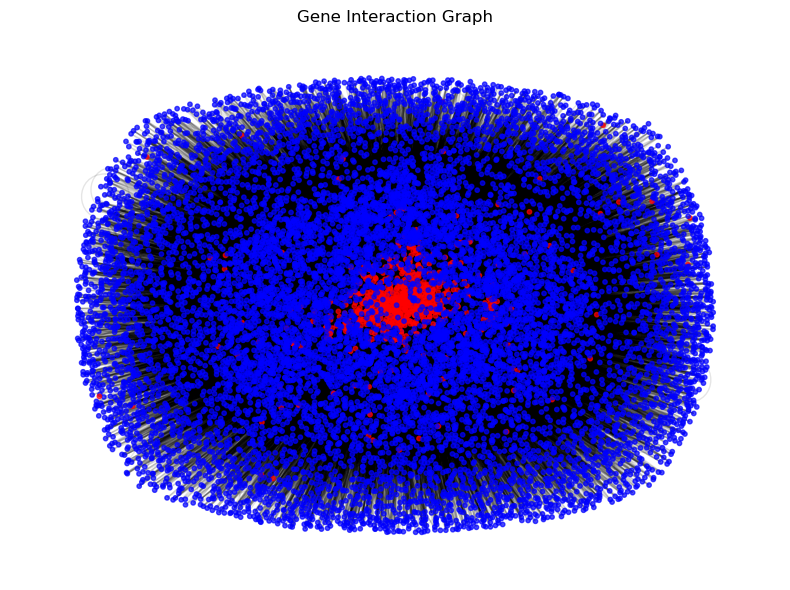

In [16]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(8, 6))

pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

# color nodes by driver presence
node_colors = [
    "red" if node in drivers else "blue"
    for node in G.nodes()
]

nx.draw_networkx_nodes(G, pos, node_size=10, node_color=node_colors, alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.title("Gene Interaction Graph")
plt.axis("off")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/graph_overview.png", dpi=300)
plt.show()

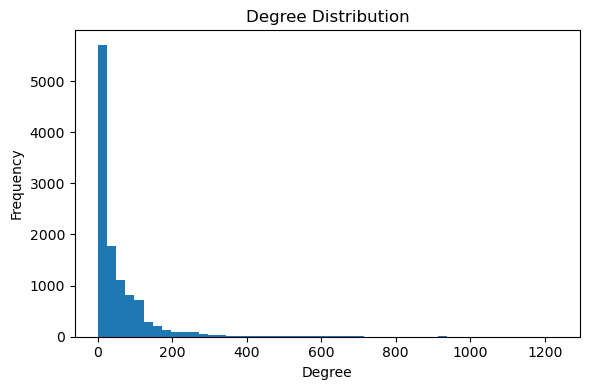

In [17]:
degrees = [d for _, d in G.degree()]

plt.figure(figsize=(6, 4))
plt.hist(degrees, bins=50)

plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/degree_distribution.png", dpi=300)
plt.show()

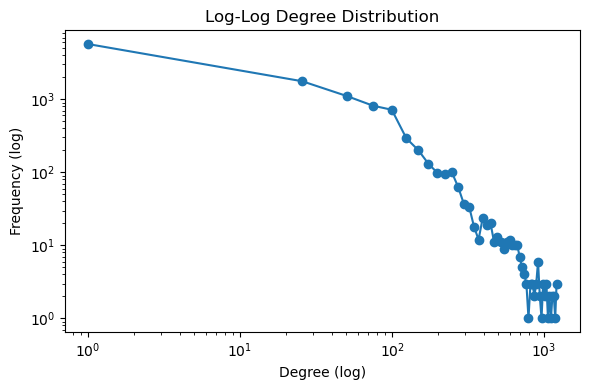

In [18]:
plt.figure(figsize=(6, 4))

hist, bins = np.histogram(degrees, bins=50)
bins = bins[:-1]

plt.loglog(bins + 1, hist + 1, marker='o')

plt.xlabel("Degree (log)")
plt.ylabel("Frequency (log)")
plt.title("Log-Log Degree Distribution")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/degree_loglog.png", dpi=300)
plt.show()

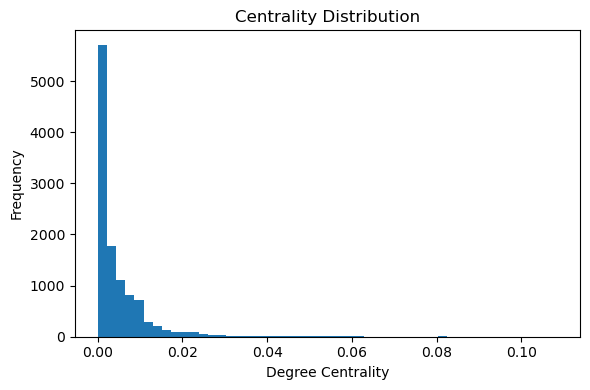

In [19]:
deg_cent = nx.degree_centrality(G)

values = list(deg_cent.values())

plt.figure(figsize=(6, 4))
plt.hist(values, bins=50)

plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")
plt.title("Centrality Distribution")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/centrality_distribution.png", dpi=300)
plt.show()

Saved plot → figures/top_hubs.png


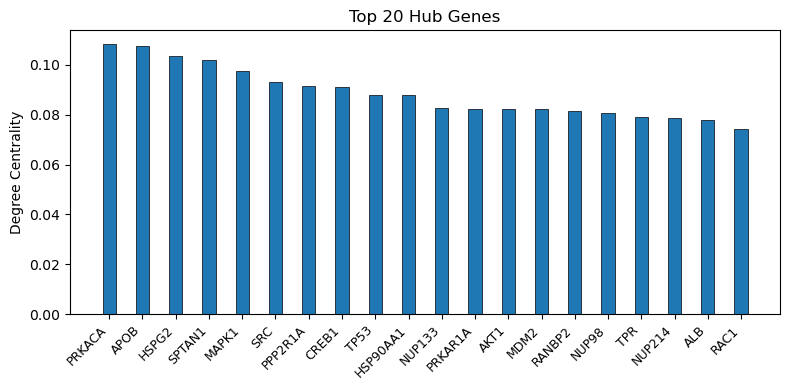

In [20]:
# ==============================
# Top Hub Genes 
# ==============================

# sort nodes by centrality (descending)
top_k = 20

sorted_nodes = sorted(
    deg_cent.items(),
    key=lambda x: x[1],
    reverse=True
)[:top_k]

genes = [g for g, _ in sorted_nodes]
scores = [s for _, s in sorted_nodes]

plt.figure(figsize=(8, 4))

plt.bar(
    genes,
    scores,
    width=0.4,
    edgecolor="black",
    linewidth=0.5
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel("Degree Centrality")
plt.title(f"Top {top_k} Hub Genes")

plt.tight_layout()

save_path = os.path.join(FIG_DIR, "top_hubs.png")
plt.savefig(save_path, dpi=300)

print(f"Saved plot → {save_path}")
plt.show()

In [21]:
try:
    import igraph as ig
    import leidenalg

    # convert to igraph
    g_ig = ig.Graph.TupleList(G.edges(), directed=False)

    partition = leidenalg.find_partition(
        g_ig,
        leidenalg.ModularityVertexPartition
    )

    communities = partition.membership

    print("Leiden communities:", len(set(communities)))

except:
    from networkx.algorithms.community import greedy_modularity_communities

    comms = list(greedy_modularity_communities(G))
    communities = {}

    for i, c in enumerate(comms):
        for node in c:
            communities[node] = i

    communities = [communities[n] for n in G.nodes()]

    print("Fallback communities:", len(set(communities)))

Leiden communities: 15


📊 Saved plot → figures/community_sizes.png


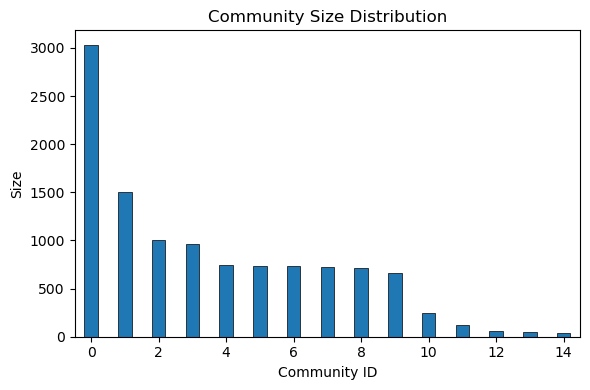

In [22]:
from collections import Counter

counts = Counter(communities)

x = list(counts.keys())
y = list(counts.values())

plt.figure(figsize=(6, 4))

plt.bar(
    x,
    y,
    width=0.4,         
    edgecolor="black",
    linewidth=0.5
)

plt.xlabel("Community ID")
plt.ylabel("Size")
plt.title("Community Size Distribution")

plt.margins(x=0.02)    
plt.tight_layout()

save_path = os.path.join(FIG_DIR, "community_sizes.png")
plt.savefig(save_path, dpi=300)
print(f"📊 Saved plot → {save_path}")

plt.show()

Graph nodes: 11372
  Driver: 687
  Non-driver: 2806
  Unlabeled: 7879


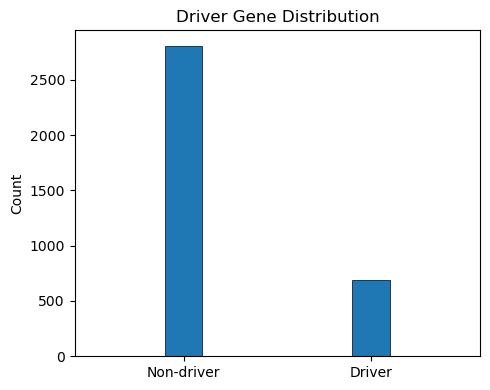

In [23]:
# NOTE: this used to reuse `counts` from the community-detection cell above
# (Counter(communities) -- Leiden/greedy-modularity community IDs), which has
# nothing to do with actual driver status. Fixed to check each graph node
# against the real `drivers` / `nondrivers` sets loaded in cell 3.
node_status = []
for node in G.nodes():
    gene = str(node).upper()
    if gene in drivers:
        node_status.append("Driver")
    elif gene in nondrivers:
        node_status.append("Non-driver")
    else:
        node_status.append("Unlabeled")

driver_counts = Counter(node_status)
print(f"Graph nodes: {G.number_of_nodes()}")
print(f"  Driver: {driver_counts.get('Driver', 0)}")
print(f"  Non-driver: {driver_counts.get('Non-driver', 0)}")
print(f"  Unlabeled: {driver_counts.get('Unlabeled', 0)}")

labels = ["Non-driver", "Driver"]
values = [driver_counts.get("Non-driver", 0), driver_counts.get("Driver", 0)]

plt.figure(figsize=(5, 4))

plt.bar(
    labels,
    values,
    width=0.2, 
    edgecolor="black",
    linewidth=0.5
)

plt.ylabel("Count")
plt.title("Driver Gene Distribution")
plt.margins(x=0.4)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "driver_distribution.png"), dpi=300)
plt.show()



📊 Saved plot → figures/edge_significance.png


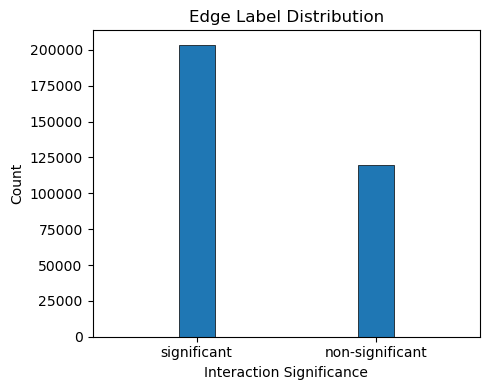

In [24]:
from collections import Counter

labels = df_final["significance"].values
counts = Counter(labels)

x_labels = list(counts.keys())
y = list(counts.values())

# map to numeric positions (like your driver plot)
x = list(range(len(x_labels)))

plt.figure(figsize=(5, 4))

plt.bar(
    x,
    y,
    width=0.2,         
    edgecolor="black",
    linewidth=0.5
)

plt.xticks(x, x_labels, rotation=0)
plt.xlabel("Interaction Significance")
plt.ylabel("Count")
plt.title("Edge Label Distribution")

plt.margins(x=0.4)    
plt.tight_layout()

save_path = os.path.join(FIG_DIR, "edge_significance.png")
plt.savefig(save_path, dpi=300)
print(f"📊 Saved plot → {save_path}")

plt.show()

In [25]:
import pickle

with open(f"{FIG_DIR}/gene_graph.gpickle", "wb") as f:
    pickle.dump(G, f)

print("✅ Graph saved.")

✅ Graph saved.
